# From a forecast to a cumulative protection target

Notebook 04 needed a forecast for one coming week. Here orders take two daily periods to arrive and the policy reviews every two days. A stock target therefore covers demand over **four future days**. We follow one external forecast through the target, order, delivery pipeline, and inventory outcome.

A forecast is not yet an inventory decision. Smooth estimates future demand and its uncertainty. Stockcast receives one dated protection target, compares it with the current inventory position, places replenishment orders, and evaluates what happens operationally.

In [1]:
import pandas as pd

# Show every number with two decimals.
pd.options.display.float_format = "{:.2f}".format

In [2]:
# These settings define one small daily inventory scenario.
sku = "tea_250g"
forecast_origin = pd.Timestamp("2026-02-14")
period_frequency = "D"
lead_time = 2
review_period = 2
service_level = 0.95
# An (R, S) target protects demand until the next order can arrive.
protection_horizon = lead_time + review_period

## 1. Split history from held-out demand

The history is available at the forecast origin and is used to fit the forecast. The later values are kept separate: they become the realized demand used by the inventory simulation.

In [3]:
# Only these observations are available when the forecast is created.
history_values = [5.0, 6.0, 4.0, 7.0, 6.0, 5.0, 8.0, 6.0, 5.0, 7.0]
history = pd.DataFrame(
    {
        "unique_id": sku,
        "date": pd.date_range(
            end=forecast_origin,
            periods=len(history_values),
            freq=period_frequency,
        ),
        "y": history_values,
    }
)

# The holdout is kept separate and later becomes realized simulation demand.
holdout_values = [7.0, 5.0, 8.0, 6.0, 4.0, 7.0, 6.0, 9.0, 5.0, 6.0, 7.0, 5.0]
holdout = pd.DataFrame(
    {
        "unique_id": sku,
        "period": range(len(holdout_values)),
        "date": pd.date_range(
            forecast_origin + pd.Timedelta(days=1),
            periods=len(holdout_values),
            freq=period_frequency,
        ),
        "y": holdout_values,
    }
)

In [4]:
# Ten observed days end exactly at the forecast origin.
assert history["date"].max() == forecast_origin

history

,unique_id,date,y
0,tea_250g,2026-02-05,5.00
1,tea_250g,2026-02-06,6.00
2,tea_250g,2026-02-07,4.00
3,tea_250g,2026-02-08,7.00
4,tea_250g,2026-02-09,6.00
5,tea_250g,2026-02-10,5.00
6,tea_250g,2026-02-11,8.00
7,tea_250g,2026-02-12,6.00
8,tea_250g,2026-02-13,5.00
9,tea_250g,2026-02-14,7.00


In [5]:
# Twelve held-out days begin the day after the origin and never overlap history.
assert holdout["date"].min() == forecast_origin + pd.Timedelta(days=1)

holdout

,unique_id,period,date,y
0,tea_250g,0,2026-02-15,7.00
1,tea_250g,1,2026-02-16,5.00
2,tea_250g,2,2026-02-17,8.00
3,tea_250g,3,2026-02-18,6.00
4,tea_250g,4,2026-02-19,4.00
5,tea_250g,5,2026-02-20,7.00
6,tea_250g,6,2026-02-21,6.00
7,tea_250g,7,2026-02-22,9.00
8,tea_250g,8,2026-02-23,5.00
9,tea_250g,9,2026-02-24,6.00


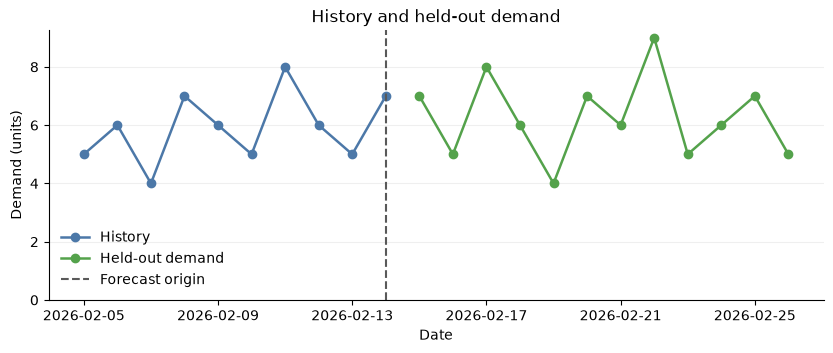

In [6]:
import matplotlib.pyplot as plt

HISTORY_COLOR = "#4C78A8"
HOLDOUT_COLOR = "#54A24B"


def style_axis(ax):
    ax.set_ylim(bottom=0)
    ax.grid(axis="y", alpha=0.2)
    ax.spines[["top", "right"]].set_visible(False)


# Plot the data boundary before fitting the forecasting model.
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(
    history["date"],
    history["y"],
    marker="o",
    linewidth=1.8,
    color=HISTORY_COLOR,
    label="History",
)
ax.plot(
    holdout["date"],
    holdout["y"],
    marker="o",
    linewidth=1.8,
    color=HOLDOUT_COLOR,
    label="Held-out demand",
)
ax.axvline(forecast_origin, color="0.35", linestyle="--", label="Forecast origin")
ax.set(title="History and held-out demand", xlabel="Date", ylabel="Demand (units)")
ax.legend(frameon=False)
style_axis(ax)
plt.show()

## 2. Forecast cumulative demand over the protection horizon

Smooth is an external forecasting package, installed separately from Stockcast. We fit a simple `ES(model='ANN')` model to the history. Its error model is normal.

The inventory target must cover the time until an order at the next review can arrive:

```text
protection horizon = lead time + review period = 2 + 2 = 4 days
```

`cumulative=True` asks Smooth for total demand across those four days. We use the cumulative upper prediction bound at the 95% service level—not a point forecast and not a sum of separate daily interval bounds.

In [7]:
from smooth import ES

# Fit one univariate exponential-smoothing model to the observed history.
model = ES(model="ANN")
model.fit(history["y"])

# This forecast keeps the four daily predictions separate for inspection.
daily_forecast = model.predict(
    h=protection_horizon,
    interval="prediction",
    level=service_level,
    side="upper",
    cumulative=False,
)

# This second call asks Smooth for the distribution of the four-day total.
cumulative_forecast = model.predict(
    h=protection_horizon,
    interval="prediction",
    level=service_level,
    side="upper",
    cumulative=True,
)

In [8]:
forecast_dates = pd.date_range(
    forecast_origin + pd.Timedelta(days=1),
    periods=protection_horizon,
    freq=period_frequency,
)
daily_forecast_output = pd.DataFrame(
    {
        "date": forecast_dates,
        "forecast_mean": daily_forecast.mean.to_numpy(),
        "daily_upper_95": daily_forecast.upper.iloc[:, 0].to_numpy(),
        "heldout_demand": holdout.loc[: protection_horizon - 1, "y"].to_numpy(),
    }
)
# Summing daily means is valid for showing expected cumulative demand.
daily_forecast_output["cumulative_mean"] = daily_forecast_output[
    "forecast_mean"
].cumsum()
daily_forecast_output["cumulative_heldout"] = daily_forecast_output[
    "heldout_demand"
].cumsum()

target_end_date = forecast_dates[-1]
forecast_output = pd.DataFrame(
    {
        "unique_id": [sku],
        "forecast_origin": [forecast_origin],
        "horizon_days": [protection_horizon],
        "target_end_date": [target_end_date],
        "cumulative_mean": [float(cumulative_forecast.mean.iloc[-1])],
        "cumulative_upper_95": [float(cumulative_forecast.upper.iloc[-1, 0])],
    }
)

In [9]:
# Four daily means with separate upper bounds, beside demand later observed.
daily_forecast_output

,date,forecast_mean,daily_upper_95,heldout_demand,cumulative_mean,cumulative_heldout
0,2026-02-15,5.90,7.99,7.00,5.90,7.00
1,2026-02-16,5.90,7.99,5.00,11.80,12.00
2,2026-02-17,5.90,7.99,8.00,17.70,20.00
3,2026-02-18,5.90,7.99,6.00,23.60,26.00


In [10]:
# Direct cumulative forecast used for the inventory target.
# This upper bound is calculated directly, never by summing daily bounds.
forecast_output

,unique_id,forecast_origin,horizon_days,target_end_date,cumulative_mean,cumulative_upper_95
0,tea_250g,2026-02-14,4,2026-02-18,23.60,27.78


### See the daily forecast and its cumulative meaning

The left panel shows the separate daily prediction means and upper bounds. The right panel accumulates only the daily means and the later observed demand. The diamond is different: it is Smooth's directly calculated upper bound for total four-day demand, which becomes the protection target. We do not add the daily upper bounds together.

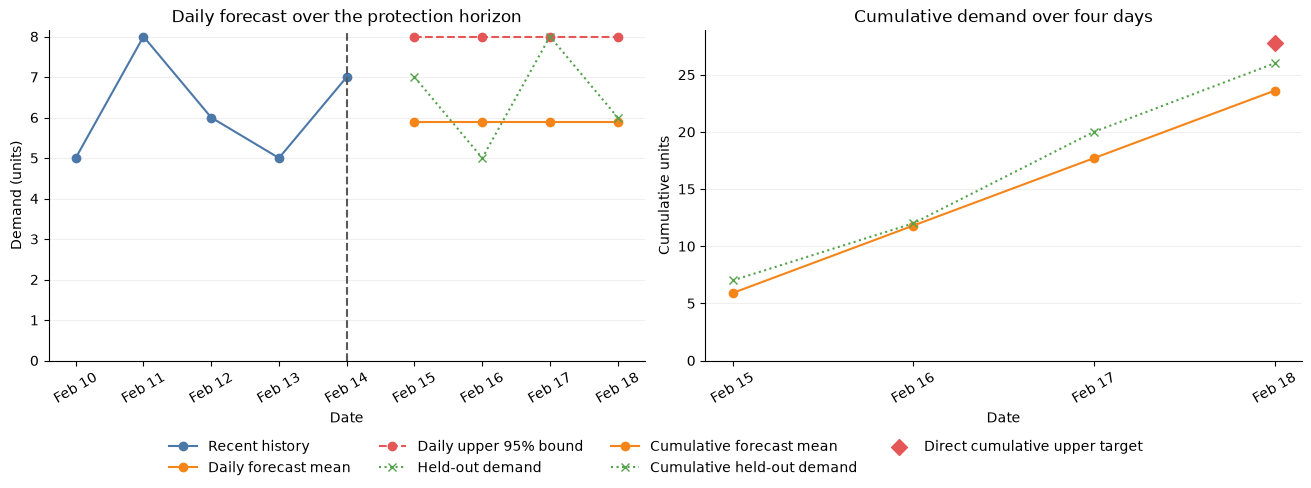

In [11]:
import matplotlib.dates as mdates

MEAN_COLOR = "#F58518"
UPPER_COLOR = "#E45756"


def format_dates(ax, dates):
    ax.set_xticks(dates)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.tick_params(axis="x", rotation=30)


recent_history = history.tail(5)
protection_target = float(forecast_output.loc[0, "cumulative_upper_95"])
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), layout="constrained")

# Daily view: compare the forecast with the demand later observed in the holdout.
axes[0].plot(
    recent_history["date"],
    recent_history["y"],
    marker="o",
    color=HISTORY_COLOR,
    label="Recent history",
)
axes[0].plot(
    daily_forecast_output["date"],
    daily_forecast_output["forecast_mean"],
    marker="o",
    color=MEAN_COLOR,
    label="Daily forecast mean",
)
axes[0].plot(
    daily_forecast_output["date"],
    daily_forecast_output["daily_upper_95"],
    marker="o",
    linestyle="--",
    color=UPPER_COLOR,
    label="Daily upper 95% bound",
)
axes[0].plot(
    daily_forecast_output["date"],
    daily_forecast_output["heldout_demand"],
    marker="x",
    linestyle=":",
    color=HOLDOUT_COLOR,
    label="Held-out demand",
)
axes[0].axvline(forecast_origin, color="0.35", linestyle="--")
axes[0].set(
    title="Daily forecast over the protection horizon",
    xlabel="Date",
    ylabel="Demand (units)",
)
format_dates(axes[0], list(recent_history["date"]) + list(forecast_dates))

# Cumulative view: the final diamond is the direct protection target.
axes[1].plot(
    daily_forecast_output["date"],
    daily_forecast_output["cumulative_mean"],
    marker="o",
    color=MEAN_COLOR,
    label="Cumulative forecast mean",
)
axes[1].plot(
    daily_forecast_output["date"],
    daily_forecast_output["cumulative_heldout"],
    marker="x",
    linestyle=":",
    color=HOLDOUT_COLOR,
    label="Cumulative held-out demand",
)
axes[1].scatter(
    target_end_date,
    protection_target,
    marker="D",
    s=65,
    color=UPPER_COLOR,
    zorder=3,
    label="Direct cumulative upper target",
)
axes[1].set(
    title="Cumulative demand over four days",
    xlabel="Date",
    ylabel="Cumulative units",
)
format_dates(axes[1], list(forecast_dates))

for ax in axes:
    style_axis(ax)

# One shared key for both panels, below the data.
handles = [h for ax in axes for h in ax.get_legend_handles_labels()[0]]
labels = [label for ax in axes for label in ax.get_legend_handles_labels()[1]]
fig.legend(handles, labels, frameon=False, loc="outside lower center", ncol=4)
plt.show()

## 3. Turn the cumulative forecast into a Stockcast target

The handoff is a small table. The target value comes directly from Smooth's cumulative upper bound. The policy reads only that value and `target_end_date`; the other columns record, for the reader, what the value represents.

In [12]:
# Keep the numerical target and its date/probability meaning in one row.
target = pd.DataFrame(
    {
        "unique_id": [sku],
        "protection_target": [forecast_output.loc[0, "cumulative_upper_95"]],
        "target_probability": [service_level],
        "protection_horizon": [protection_horizon],
        "forecast_origin": [forecast_origin],
        "forecast_frequency": [period_frequency],
        "target_end_date": [target_end_date],
        "representation": ["cumulative_upper_prediction_interval"],
        "target_source": ["external_direct"],
    }
)
target

,unique_id,protection_target,target_probability,protection_horizon,forecast_origin,forecast_frequency,target_end_date,representation,target_source
0,tea_250g,27.78,0.95,4,2026-02-14,D,2026-02-18,cumulative_upper_prediction_interval,external_direct


## 4. Convert the target into an order decision

Opening stock is a separate inventory input; it is not estimated from the forecast. The `(R, S)` policy from `stockcast.policies` compares the target `S` with the inventory position, which is the stock on hand plus the orders still on their way, and requests the difference.

In [13]:
# Opening stock is a declared inventory input, independent of the forecast.
opening_stock = pd.DataFrame({"unique_id": [sku], "observed_on_hand": [12.0]})
opening_stock

,unique_id,observed_on_hand
0,tea_250g,12.00


In [14]:
from stockcast.core import InventoryStateDataFrame

# Your working object; the engine deep-copies it at run time.
empty_state = InventoryStateDataFrame(
    [sku],
    max_lead_time=lead_time,
    allow_backorders=False,
)
opening_inventory = empty_state.initialize_from_observed(
    opening_stock,
    on_hand_column="observed_on_hand",
    opening_date=forecast_origin,
)
opening_inventory

InventoryStateDataFrame(n_skus=1, total_on_hand=12, total_backorders=0, has_stockout=False, has_backorder=False)

In [15]:
from stockcast.policies import OrderUpToPolicy

policy = OrderUpToPolicy(
    lead_time=lead_time,  # 2-day delivery delay; order enters pipeline, not on-hand.
    review_period=review_period,  # Review every 2 days; only those periods may order.
    freq=period_frequency,  # Daily steps; must match demand and state frequency.
    service_level=service_level,  # 95% protection; the target is read as this quantile.
    allow_backorders=False,  # Lost sales; matches the opening state, unmet demand is lost.
    date_column="target_end_date",  # Must equal origin + H; validated.
)

# Fitting checks that target_end_date is H = L + R days after the forecast origin.
policy.fit(
    target,  # One externally calculated cumulative target row for this SKU.
    target_column="protection_target",  # S value: direct 4-day cumulative upper bound.
    forecast_origin=forecast_origin,  # Info date; history ends here, holdout starts next day.
)

# The policy orders up from inventory position to the fitted target level.
opening_decision = policy.predict(opening_inventory, current_period=0)
opening_position = opening_inventory.inventory_position()
opening_position[["unique_id", "on_hand", "total_in_transit", "inventory_position"]]

,unique_id,on_hand,total_in_transit,inventory_position
0,tea_250g,12.00,0.00,12.00


In [16]:
# Order quantity = target level - inventory position: 27.78 - 12.00 = 15.78.
decision_columns = [
    "unique_id",
    "order_quantity",
    "target_level",
    "inventory_position",
    "order_period",
    "expected_delivery_period",
]
opening_decision.get_dataframe()[decision_columns]

,unique_id,order_quantity,target_level,inventory_position,order_period,expected_delivery_period
0,tea_250g,15.78,27.78,12.00,0,2


## 5. Simulate on held-out demand

`SimulationEngine` from `stockcast.core` begins with the declared opening stock, decides before the first held-out demand, and moves accepted orders through a two-day pipeline. All twelve held-out days are scored. This first cumulative example deliberately holds its original target fixed so the effect of timing and stock position is easy to see; Notebook 04d updates it as new demand becomes available.

In [17]:
from stockcast.core import SimulationEngine

# The engine receives the held-out demand exactly as declared above.
result = SimulationEngine().run(
    policy=policy,  # Fitted (R,S) policy; engine deep-copies it.
    demand_source=holdout,  # 12 realized days unseen by the forecast; consumed in every window.
    inventory=opening_inventory,  # Explicit opening state at the origin; also deep-copied.
)

In [18]:
# This is the engine's copy; `opening_inventory` above is unchanged.
result.inventory


InventoryStateDataFrame(n_skus=1, total_on_hand=5, total_backorders=0, has_stockout=False, has_backorder=False)

## 6. Read the operational result

The event table is Stockcast's record of the run: one row per day with the demand, the order placed, the units received, and the stock left at the end of the day. Orders are not received the day they are placed. They arrive two days later, so each receipt below matches an order from two rows earlier.

In [19]:
# Follow the accepted order from decision through receipt and demand.
events = result.to_event_frame(window="all")
period_events = events.loc[events["event_type"].eq("period")].copy()
event_columns = [
    "date",
    "demand",
    "order_quantity",
    "received_units",
    "ending_on_hand",
    "on_order_end",
    "shortage_units",
]
period_events[event_columns].reset_index(drop=True)

,date,demand,order_quantity,received_units,ending_on_hand,on_order_end,shortage_units
0,2026-02-15,7.00,15.78,0.00,5.00,15.78,0.00
1,2026-02-16,5.00,0.00,0.00,0.00,15.78,0.00
2,2026-02-17,8.00,12.00,15.78,7.78,12.00,0.00
3,2026-02-18,6.00,0.00,0.00,1.78,12.00,0.00
4,2026-02-19,4.00,14.00,12.00,9.78,14.00,0.00
5,2026-02-20,7.00,0.00,0.00,2.78,14.00,0.00
6,2026-02-21,6.00,11.00,14.00,10.78,11.00,0.00
7,2026-02-22,9.00,0.00,0.00,1.78,11.00,0.00
8,2026-02-23,5.00,15.00,11.00,7.78,15.00,0.00
9,2026-02-24,6.00,0.00,0.00,1.78,15.00,0.00


In [20]:
# The target's meaning travels with the simulation result.
pd.DataFrame([result.run_manifest["policy"]["target_metadata"]])

,representation,target_probability,protection_horizon,target_source,forecast_origin,forecast_frequency,target_end_date
0,direct_protection_period_target,0.95,4,external_direct,2026-02-14T00:00:00,D,2026-02-18T00:00:00


In [21]:
from stockcast.evaluation import (
    InventoryEvaluator,
    avg_on_hand,
    demand_period_service_level,
    fill_rate,
    order_units,
)

# Metrics are calculated only from validated held-out event rows.
evaluator = InventoryEvaluator()
evaluator.fit(simulation_result=result, window="scoring")
evaluator.evaluate(
    metrics=[fill_rate, demand_period_service_level, avg_on_hand, order_units],
    groupby=[],
)

,fill_rate,demand_period_service_level,avg_on_hand,order_units
0,1.00,1.00,5.31,78.78


### See demand, replenishment, and inventory together

The middle panel separates orders from receipts. An order is accepted into the lead-time pipeline when it is placed; it becomes physical stock only when it appears as a receipt. The bottom panel therefore shows on-hand stock and unreceived pipeline stock separately. The target stayed at 27.78 units for all twelve days; Notebook 04d refreshes it as demand arrives.

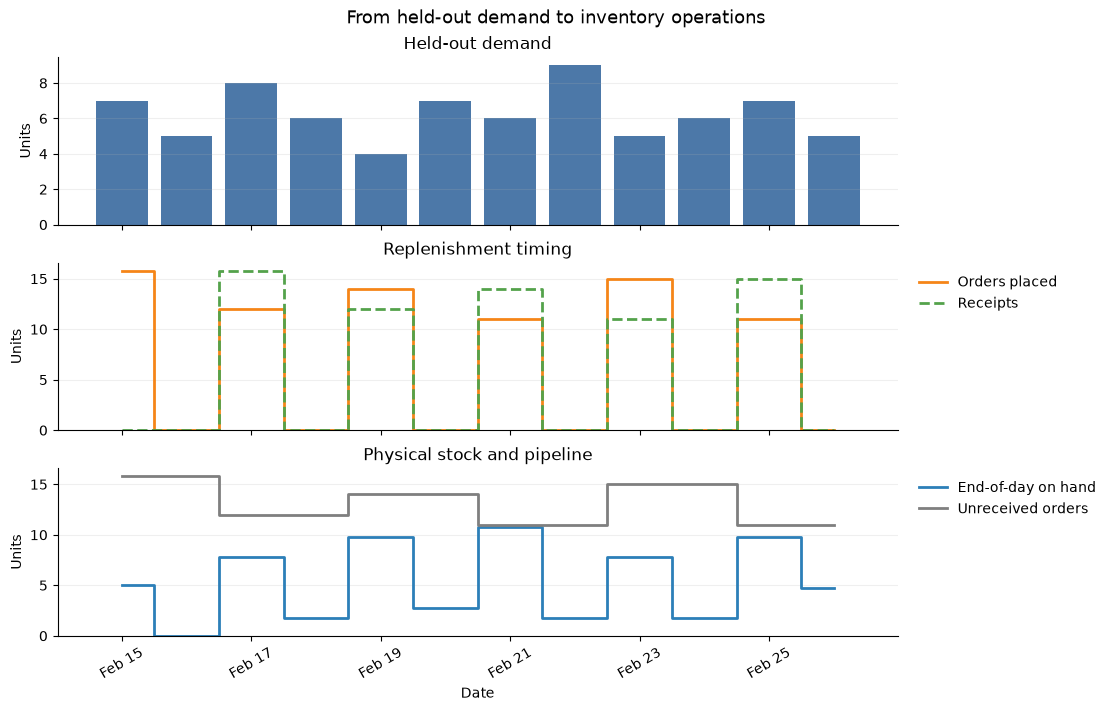

In [22]:
ORDER_COLOR = "#F58518"
STOCK_COLOR = "#2C7FB8"
PIPELINE_COLOR = "#7F7F7F"

dates = period_events["date"]
# Separate panels prevent differently scaled flows and states from competing.
fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True, layout="constrained")

axes[0].bar(dates, period_events["demand"], color=HISTORY_COLOR)
axes[0].set(title="Held-out demand", ylabel="Units")

axes[1].step(
    dates,
    period_events["order_quantity"],
    where="mid",
    color=ORDER_COLOR,
    linewidth=2,
    label="Orders placed",
)
axes[1].step(
    dates,
    period_events["received_units"],
    where="mid",
    color=HOLDOUT_COLOR,
    linewidth=2,
    linestyle="--",
    label="Receipts",
)
axes[1].set(title="Replenishment timing", ylabel="Units")

axes[2].step(
    dates,
    period_events["ending_on_hand"],
    where="mid",
    color=STOCK_COLOR,
    linewidth=2,
    label="End-of-day on hand",
)
axes[2].step(
    dates,
    period_events["on_order_end"],
    where="mid",
    color=PIPELINE_COLOR,
    linewidth=2,
    label="Unreceived orders",
)
axes[2].set(title="Physical stock and pipeline", xlabel="Date", ylabel="Units")

# Put the keys outside the data area so no trajectory is hidden.
axes[1].legend(frameon=False, loc="upper left", bbox_to_anchor=(1.01, 1.0))
axes[2].legend(frameon=False, loc="upper left", bbox_to_anchor=(1.01, 1.0))
for ax in axes:
    style_axis(ax)
format_dates(axes[2], list(dates[::2]))
fig.suptitle("From held-out demand to inventory operations", fontsize=13)
plt.show()